In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("unclean_customer_data.csv")
df.head()


,Customer_ID,Age,Annual_Income,Spending_Score,Purchase_Frequency,Transaction_Amount
0,8270,31.0,75851.592212,77.104268,17,129.724190
1,1860,48.0,44460.183764,61.349076,25,91.479265
2,6390,17.0,43677.755605,22.589956,9,130.573812
3,6191,34.0,48666.812544,82.069525,0,72.395846
4,6734,44.0,46080.334029,65.076915,3,156.399077


In [3]:
missing_counts = df.isnull().sum()
print(missing_counts)


Customer_ID             0
Age                   257
Annual_Income           0
Spending_Score          0
Purchase_Frequency      0
Transaction_Amount    256
dtype: int64


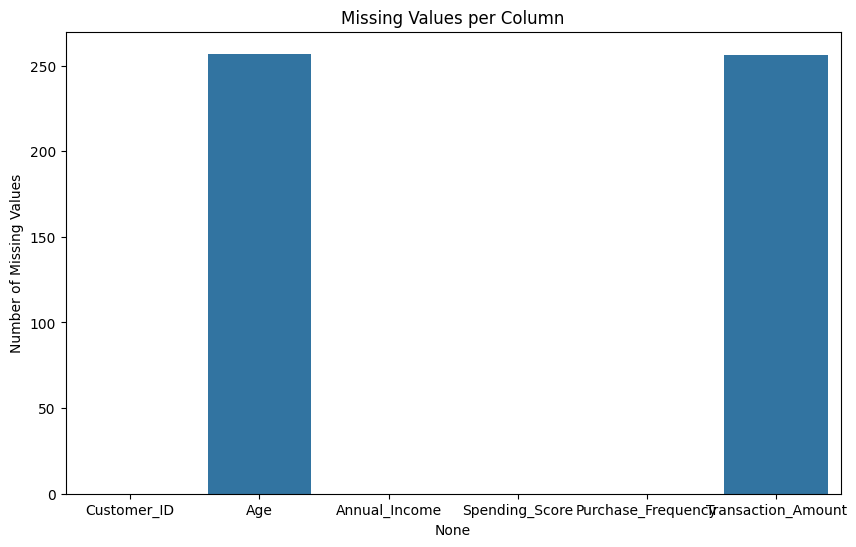

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x=missing_counts.index, y=missing_counts.values)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column")
plt.show()


In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Transaction_Amount"] = df["Transaction_Amount"].fillna(df["Transaction_Amount"].median())

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Define rfm using relevant numerical columns from df
# Assuming 'Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Transaction_Amount' are the features for clustering
rfm = df[['Age', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Transaction_Amount']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

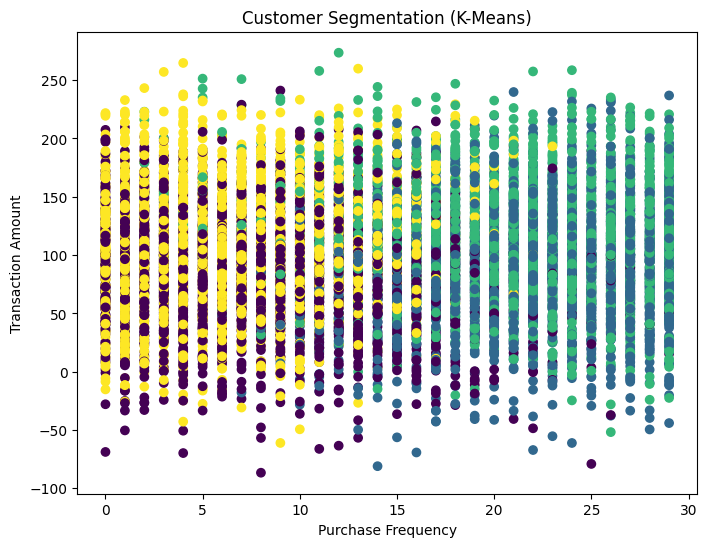

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(rfm["Purchase_Frequency"], rfm["Transaction_Amount"], c=rfm["Cluster"], cmap="viridis")
plt.xlabel("Purchase Frequency")
plt.ylabel("Transaction Amount")
plt.title("Customer Segmentation (K-Means)")
plt.show()

In [15]:
rfm.to_csv("segmented_customers.csv", index=True)
